<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2026-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1
## Starting Point for Exercise 1, part II

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part II.

One of the goals of this exercise is to make you acquainted with **skorch**. You will probably need to consult the [documentation](https://skorch.readthedocs.io/en/stable/).

## Use of generative AI

AI tools may be used in this exercise to help you explain code, debug, improve documentation, and explore alternatives. Any use must be documented in the *Declaration on the use of AI* at the end of this notebook (which tools were used and for which purposes). You remain responsible for understanding, checking, and testing everything you submit, and you must be able to explain any submitted text, code, analyses, and AI-assisted contributions. See the [CL guidelines on academic integrity and AI use](https://www.cl.uzh.ch/en/Studies/Services/academic-integrity.html).

# Setup

In [1]:
# Pin the library versions used in this course (the same ones as in Part I and the W04 tutorial).
# PyTorch is preinstalled on Colab; for a local installation see https://pytorch.org/get-started/locally/
%pip install -q scikit-learn==1.9.1 skorch==1.4.0 gdown

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier

import pandas as pd
import numpy as np
import csv
import re
import string
from collections import defaultdict

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Training a classifier and making predictions

In [3]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Using cookies from /home/jovyan/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /home/jovyan/x_train.txt
100%|██████████████████████████████████████| 64.1M/64.1M [00:00<00:00, 167MB/s]
Using cookies from /home/jovyan/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6
To: /home/jovyan/x_test.txt
100%|██████████████████████████████████████| 65.2M/65.2M [00:00<00:00, 173MB/s]
Using cookies from /home/jovyan/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl
To: /home/jovyan/y_train.txt
100%|███████████████████████████████████████| 480k/480k [00:00<00:00, 90.2MB/s]
Using cookies from /home/jovyan/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X
To: /home/jovyan/y_test.txt
100%|███████████████████████████████████████| 480k/480k [00:00<00:00, 51.3

In [4]:
with open('x_train.txt') as f:
    x_train = f.read().splitlines()
with open('y_train.txt') as f:
    y_train = f.read().splitlines()
with open('x_test.txt') as f:
    x_test = f.read().splitlines()
with open('y_test.txt') as f:
    y_test = f.read().splitlines()

In [5]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Combine x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


### Data preparation

Prepare your dataset for this experiment using the same method as you did in part 1.

Get a subset of the train/test data that includes 20 languages. Include English (`eng`), German (`deu`), Dutch (`nld`), Danish (`dan`), Swedish (`swe`), Norwegian (either Bokmål `nob` or Nynorsk `nno`), and Japanese (`jpn`), plus 13 additional languages of your choice based on the items in the list of labels.

Unlike `sklearn`, the neural network cannot work with string labels: `skorch` and `CrossEntropyLoss` expect the labels as integer class indices `0, ..., n_classes - 1`. We therefore encode them with a [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).


In [6]:
# TODO: Create your train/test subsets of languages
# Note, make sure these are the same as what you used in Part 1!

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

selected_labels = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn']
additional_labels = ['fra', 'spa', 'ita', 'rus', 'ara', 'hin', 'zho', 'asm', 'heb', 'kan', 'kor', 'tha', 'vie']
all_labels = sorted(selected_labels + additional_labels)

train_test_df = pd.concat([train_df, test_df]).sample(frac=1, random_state=42).reset_index(drop=True)
train_test_df = train_test_df[train_test_df['label'].isin(all_labels)].drop_duplicates(subset=['text'])

x_train, x_test, y_train, y_test = train_test_split(
    train_test_df['text'], 
    train_test_df['label'],
    test_size=0.2, 
    stratify=train_test_df['label'], 
    random_state=42
)

In [7]:
# TODO: With the following code, we wanted to ENCODE the labels, however, our cat was walking on the keyboard and some of it got changed. Can you fix it?
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(y_train)
y_train, y_test = label_encoder.transform(y_train), label_encoder.transform(y_test)
print(label_encoder.classes_)
print(y_train)
print(y_test)

['ara' 'asm' 'dan' 'deu' 'eng' 'fra' 'heb' 'hin' 'ita' 'jpn' 'kan' 'kor'
 'nld' 'nob' 'rus' 'spa' 'swe' 'tha' 'vie' 'zho']
[2 2 5 ... 6 9 2]
[19 12 11 ...  8 18 14]


### Feature Extraction

In [8]:
# First, we extract some simple features as input for the neural network
# Note: x_train and y_train must refer to your 20-language subset from above, not to the full dataset
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 2), max_features=100, binary=True)
X = vectorizer.fit_transform(x_train)

In [9]:
# We need to change the datatype to make it play nice with pytorch
X = X.astype(np.float32)
y = y_train.astype(np.int64)

In the following, we define a vanilla neural network with two hidden layers. The output layer should have as many outputs as there are classes. In addition, it should have a nonlinearity function.

In [10]:
# TODO: In the following, you can find a small (almost) working example of a neural network.
# Unfortunately, again, the cat messed up some of the code. Please fix the code such that it is executable. (Hint: the input and output sizes look a bit weird...)

class ClassifierModule(nn.Module):
    def __init__(
        self,
        input_size=100,
        num_classes=20,
        num_units=200,
        nonlin=F.relu,
    ):
        super(ClassifierModule, self).__init__()
        self.num_units = num_units
        self.nonlin = nonlin

        self.dense0 = nn.Linear(input_size, num_units)
        self.dense1 = nn.Linear(num_units, 50)
        
        self.output = nn.Linear(50, num_classes)

    def forward(self, X, **kwargs):
        X = self.nonlin(self.dense0(X))
        
        X = self.nonlin(self.dense1(X))
        
        X = self.output(X)
        return X

In [11]:
# Initialise the neural net classifier.
net = NeuralNetClassifier(
    ClassifierModule(
        input_size=X.shape[1],
        num_units=200,
        num_classes=len(label_encoder.classes_),
        nonlin=F.relu,
    ),
    max_epochs=20,
    criterion=nn.CrossEntropyLoss(),
    lr=0.1,
    device='cuda' if torch.cuda.is_available() else 'cpu',   # train on the GPU if Colab gives you one
)

In [12]:
# Train the classifier
net.fit(X, y)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.6797       0.2937        2.4071  0.7639
      2        2.0918       0.3882        1.8231  0.7407
      3        1.6630       0.4523        1.5398  0.7633
      4        1.4423       0.5302        1.3717  0.7625
      5        1.2866       0.5577        1.2464  0.7744
      6        1.1794       0.5759        1.1685  0.7495
      7        1.1171       0.5821        1.1260  0.7265
      8        1.0812       0.5924        1.1015  0.7606
      9        1.0565       0.5952        1.0849  0.7509
     10        1.0377       0.5996        1.0731  0.7555
     11        1.0226       0.6024        1.0641  0.7468
     12        1.0101       0.6046        1.0573  0.7532
     13        0.9995       0.6049        1.0519  0.7558
     14        0.9903       0.6074        1.0488  0.7708
     15        0.9821       0.6078        1.0453  0.7281
     16        0.9747       0.6

,module,"ClassifierMod..., bias=True) )"
,criterion,CrossEntropyLoss()
,optimizer,<class 'torch.optim.sgd.SGD'>
,lr,0.1
,max_epochs,20
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>
,callbacks,None
,predict_nonlinearity,'auto'


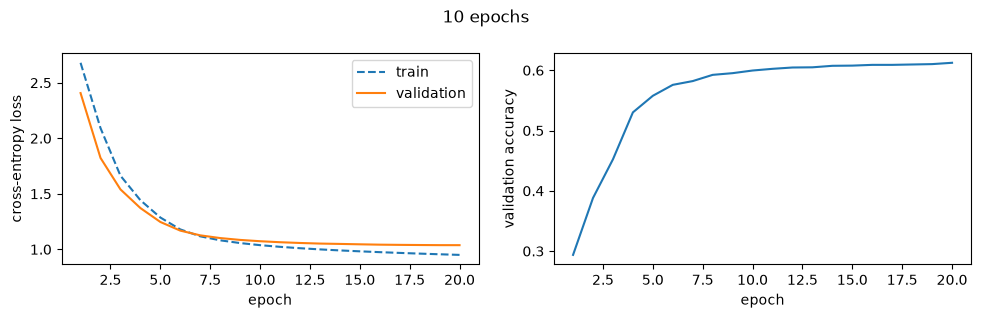

In [13]:
import matplotlib.pyplot as plt

def plot_history(net, title):
    """Validation loss and accuracy per epoch, from the history that skorch keeps during fit."""
    epochs = net.history[:, 'epoch']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(epochs, net.history[:, 'train_loss'], '--', label='train')
    axes[0].plot(epochs, net.history[:, 'valid_loss'], label='validation')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy loss'); axes[0].legend()
    axes[1].plot(epochs, net.history[:, 'valid_acc'])
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('validation accuracy')
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_history(net, '10 epochs')

Note, you can also use `GridSearchCV` with `skorch` (it follows the `sklearn` API), but be aware that training a neural network takes much more time; a handful of hand-picked configurations, compared on the validation split that `skorch` holds out for you, is enough here.

Play around with 5 different sets of hyperparameters. For example, consider some of the following:

- layer sizes
- activation functions
- regularizers
- early stopping
- vectorizer parameters (`max_features`, `ngram_range`)

Report your best hyperparameter combination.

📝❓ What is the effect of your modifications on validation performance? Discuss potential reasons.

In [14]:
from skorch.callbacks import EarlyStopping
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 1. DENSE + FLOAT32 TRANSFORMER

class DenseFloat32Transformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        return X.astype(np.float32)

# 2. NEURAL NETWORK

class ClassifierModule(nn.Module):
    def __init__(
        self,
        num_classes=20,
        num_units=200,
        num_units2=50,
        nonlin=F.relu,
        dropout_rate=0.0
    ):
        super(ClassifierModule, self).__init__()
        self.nonlin = nonlin
        self.drop = nn.Dropout(dropout_rate)
        # First hidden layer
        self.dense0 = nn.LazyLinear(num_units)
        # Second hidden layer
        self.dense1 = nn.Linear(num_units, num_units2)
        # Output layer
        self.output = nn.Linear(num_units2, num_classes)


    def forward(self, X, **kwargs):
        # First hidden layer
        X = self.nonlin(self.dense0(X))
        X = self.drop(X)
        # Second hidden layer
        X = self.nonlin(self.dense1(X))
        X = self.drop(X)
        # Output layer
        X = self.output(X)
        return X

# 3. PIPELINE

pipeline = Pipeline([
    (
        'vect',
        TfidfVectorizer(
            analyzer='char'
        )
    ),
    (
        'todense',
        DenseFloat32Transformer()
    ),
    (
        'net',
        NeuralNetClassifier(
            ClassifierModule,
            module__num_classes=len(label_encoder.classes_),
            # Maximum number of epochs
            max_epochs=30,
            # Loss function
            criterion=nn.CrossEntropyLoss,
            # Learning rate is not fixed here, will be specified separately for each configuration in param_grid.
            # Early stopping
            callbacks=[
                EarlyStopping(
                    monitor='valid_loss',
                    patience=5
                )
            ],
            device='cuda' if torch.cuda.is_available() else 'cpu',
            verbose=0
        )
    )
])


# 4. PARAMETER GRID

param_grid = [
    # SET 1: Small baseline
    # Adam + lr = 0.001
    {
        'vect__max_features': [2000],
        'vect__ngram_range': [(2, 3)],
        'net__module__num_units': [200],
        'net__module__num_units2': [50],
        'net__module__nonlin': [F.relu],
        'net__module__dropout_rate': [0.0],
        'net__optimizer': [optim.Adam],
        'net__lr': [0.001],
    },

    # SET 2: Larger network + dropout
    # Adam + lr = 0.001
    {
        'vect__max_features': [5000],
        'vect__ngram_range': [(2, 3)],
        'net__module__num_units': [500],
        'net__module__num_units2': [100],
        'net__module__nonlin': [F.relu],
        'net__module__dropout_rate': [0.3],
        'net__optimizer': [optim.Adam],
        'net__lr': [0.001],
    },

    # SET 3: Tanh + longer character n-grams
    # Adam + lr = 0.001
    {
        'vect__max_features': [5000],
        'vect__ngram_range': [(3, 5)],
        'net__module__num_units': [500],
        'net__module__num_units2': [100],
        'net__module__nonlin': [torch.tanh],
        'net__module__dropout_rate': [0.3],
        'net__optimizer': [optim.Adam],
        'net__lr': [0.001],
    },

    # SET 4: Large network + strong regularization
    # Adam + lr = 0.001
    {
        'vect__max_features': [10000],
        'vect__ngram_range': [(2, 5)],
        'net__module__num_units': [500],
        'net__module__num_units2': [200],
        'net__module__nonlin': [F.relu],
        'net__module__dropout_rate': [0.5],
        'net__optimizer': [optim.Adam],
        'net__lr': [0.001],
    },

    # SET 5: Moderate network + SGD
    # SGD + lr = 0.01
    {
        'vect__max_features': [5000],
        'vect__ngram_range': [(2, 4)],
        'net__module__num_units': [300],
        'net__module__num_units2': [100],
        'net__module__nonlin': [F.relu],
        'net__module__dropout_rate': [0.2],
        'net__optimizer': [optim.SGD],
        'net__lr': [0.01],
    }
]
# 5. PREPARE TARGET
y_train_idx = y_train.astype(np.int64)

# 6. GRID SEARCH
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=1
)

grid_search.fit(
    x_train,
    y_train_idx
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END net__lr=0.001, net__module__dropout_rate=0.0, net__module__nonlin=<function relu at 0x7de1da09dee0>, net__module__num_units=200, net__module__num_units2=50, net__optimizer=<class 'torch.optim.adam.Adam'>, vect__max_features=2000, vect__ngram_range=(2, 3); total time=   8.9s
[CV] END net__lr=0.001, net__module__dropout_rate=0.0, net__module__nonlin=<function relu at 0x7de1da09dee0>, net__module__num_units=200, net__module__num_units2=50, net__optimizer=<class 'torch.optim.adam.Adam'>, vect__max_features=2000, vect__ngram_range=(2, 3); total time=   9.4s
[CV] END net__lr=0.001, net__module__dropout_rate=0.0, net__module__nonlin=<function relu at 0x7de1da09dee0>, net__module__num_units=200, net__module__num_units2=50, net__optimizer=<class 'torch.optim.adam.Adam'>, vect__max_features=2000, vect__ngram_range=(2, 3); total time=   9.4s
[CV] END net__lr=0.001, net__module__dropout_rate=0.3, net__module__nonlin=<function rel

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tart=False))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'net__lr': [0.001], 'net__module__dropout_rate': [0.0], 'net__module__nonlin': [<function rel...x7de1da09dee0>], 'net__module__num_units': [200], ...}, {'net__lr': [0.001], 'net__module__dropout_rate': [0.3], 'net__module__nonlin': [<function rel...x7de1da09dee0>], 'net__module__num_units': [500], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only b

In [15]:
# 7. BEST MODEL
print(
    f"Best CV Accuracy: "
    f"{grid_search.best_score_:.4f}"
)
print("\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

# 8. GET GRID SEARCH RESULTS
results = pd.DataFrame(
    grid_search.cv_results_
)
# 9. CREATE CLEAN COMPARISON TABLE
clear_results = pd.DataFrame({

    'Configuration': [
        1,  # Small baseline
        2,  # Larger network + dropout
        3,  # Tanh + longer n-grams
        4,  # Large network + strong regularization
        5   # Moderate network + SGD
    ],
    'CV Accuracy':
        results['mean_test_score'],
    'Std. Dev.':
        results['std_test_score'],
    'Max Features':
        results['param_vect__max_features'],
    'N-gram Range':
        results['param_vect__ngram_range'],
    'Layer 1':
        results['param_net__module__num_units'],
    'Layer 2':
        results['param_net__module__num_units2'],
    'Activation':
        results['param_net__module__nonlin'].apply(
            lambda x:
                'ReLU'
                if x == F.relu
                else 'Tanh'
        ),
    'Dropout':
        results['param_net__module__dropout_rate'],
    'Optimizer':
        results['param_net__optimizer'].apply(
            lambda x:
                'Adam'
                if x == optim.Adam
                else 'SGD'
        ),
    'Learning Rate':
        results['param_net__lr']
})
# 10. CONVERT ACCURACY TO PERCENTAGE

clear_results['CV Accuracy'] = (
    clear_results['CV Accuracy'] * 100
)
clear_results['Std. Dev.'] = (
    clear_results['Std. Dev.'] * 100
)

# 11. SORT BEST to WORST

clear_results = clear_results.sort_values(
    'CV Accuracy',
    ascending=False
).reset_index(drop=True)

# 12. DISPLAY RESULTS
display(clear_results)

Best CV Accuracy: 0.9849

Best Parameters:
  net__lr: 0.001
  net__module__dropout_rate: 0.5
  net__module__nonlin: <function relu at 0x7de1da09dee0>
  net__module__num_units: 500
  net__module__num_units2: 200
  net__optimizer: <class 'torch.optim.adam.Adam'>
  vect__max_features: 10000
  vect__ngram_range: (2, 5)


,Configuration,CV Accuracy,Std. Dev.,Max Features,N-gram Range,Layer 1,Layer 2,Activation,Dropout,Optimizer,Learning Rate
0,4,98.485986,0.046818,10000,"(2, 5)",500,200,ReLU,0.5,Adam,0.001
1,2,98.404655,0.085324,5000,"(2, 3)",500,100,ReLU,0.3,Adam,0.001
2,1,97.804054,0.100490,2000,"(2, 3)",200,50,ReLU,0.0,Adam,0.001
3,3,97.716466,0.061934,5000,"(3, 5)",500,100,Tanh,0.3,Adam,0.001
4,5,23.442192,6.772587,5000,"(2, 4)",300,100,ReLU,0.2,SGD,0.010


☝ Note, during model development, if you run into the infamous CUDA out-of-memory (OOM) error, try clearing the GPU memory either with `torch.cuda.empty_cache()` or restarting the runtime.

In [16]:
# TRAIN BEST MODEL SEPARATELY

from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# 1. BEST MODEL CONFIGURATION
best_model = Pipeline([
    # TF-IDF character features
    (
        'vect',
        TfidfVectorizer(
            analyzer='char',
            max_features=10000,
            ngram_range=(2, 5)
        )
    ),
    # Convert sparse matrix to dense float32
    (
        'todense',
        DenseFloat32Transformer()
    ),
    # Neural network
    (
        'net',
        NeuralNetClassifier(
            ClassifierModule,
            # Number of classes
            module__num_classes=len(label_encoder.classes_),
            # Best architecture
            module__num_units=500,
            module__num_units2=200,
            module__nonlin=F.relu,
            module__dropout_rate=0.5,
            # Best optimizer
            optimizer=optim.Adam,
            # Best learning rate
            lr=0.001,
            # Training
            max_epochs=30,
            # Loss function
            criterion=nn.CrossEntropyLoss,
            # Early stopping
            callbacks=[
                EarlyStopping(
                    monitor='valid_loss',
                    patience=5
                )
            ],
            # Let skorch use its default validation split
            device='cuda' if torch.cuda.is_available() else 'cpu',
            verbose=1
        )
    )
])
# 2. PREPARE TARGET
y_train_idx = y_train.astype(np.int64)
# 3. TRAIN BEST MODEL
best_model.fit(
    x_train,
    y_train_idx
)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.1336       0.9618        0.1558  1.8828
      2        0.1114       0.9812        0.0851  1.8442
      3        0.0542       0.9831        0.0732  1.8263
      4        0.0330       0.9840        0.0669  1.7942
      5        0.0212       0.9859        0.0669  1.8110
      6        0.0117       0.9850        0.0699  1.7565
      7        0.0070       0.9853        0.0700  1.8247
      8        0.0063       0.9853        0.0743  1.9723
      9        0.0052       0.9856        0.0752  1.9779
Stopping since valid_loss has not improved in the last 5 epochs.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vect', ...), ('todense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](20,)","[ 0, 1, 2,...,17,18,19]"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(2, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [17]:
# 4. PREDICT ON TEST SET
y_pred = best_model.predict(x_test)

# 5. TEST ACCURACY
print("TEST SET RESULTS")
print(
    f"\nTest Accuracy: "
    f"{accuracy_score(y_test, y_pred):.3f}"
)

TEST SET RESULTS

Test Accuracy: 0.986


In [19]:
# 6. CLASSIFICATION REPORT
target_names = label_encoder.classes_
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        digits=3,
        zero_division=0
    )
)


Classification Report:

              precision    recall  f1-score   support

         ara      1.000     1.000     1.000       200
         asm      1.000     0.970     0.985       200
         dan      0.970     0.980     0.975       200
         deu      0.990     0.995     0.993       200
         eng      0.888     0.995     0.939       200
         fra      0.985     0.990     0.987       198
         heb      1.000     0.995     0.997       200
         hin      1.000     0.975     0.987       200
         ita      0.985     0.995     0.990       200
         jpn      0.990     0.960     0.975       200
         kan      1.000     1.000     1.000       200
         kor      1.000     0.980     0.990       200
         nld      1.000     0.990     0.995       200
         nob      0.990     0.970     0.980       200
         rus      1.000     0.980     0.990       200
         spa      0.995     0.990     0.992       199
         swe      1.000     0.995     0.997       199
  


Confusion Matrix:

[[200   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0 194   0   0   6   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0 196   1   2   0   0   0   0   0   0   0   0   1   0   0   0   0
    0   0]
 [  0   0   0 199   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0 199   0   0   0   1   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   2 196   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0 199   0   0   0   0   0   0   0   0   0   0   0
    0   1]
 [  0   0   0   0   5   0   0 195   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   1   0   0   0 199   0   0   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   1   1   0   0   0 192   0   0   0   0   0   0   0   0
    0   6]
 [  0   0   0   0   0   0   0   0   0   0 200   0   0   0   0   0   0   0
    0   0]
 [  0   0   0   0   0   0   0   0   0   0   0

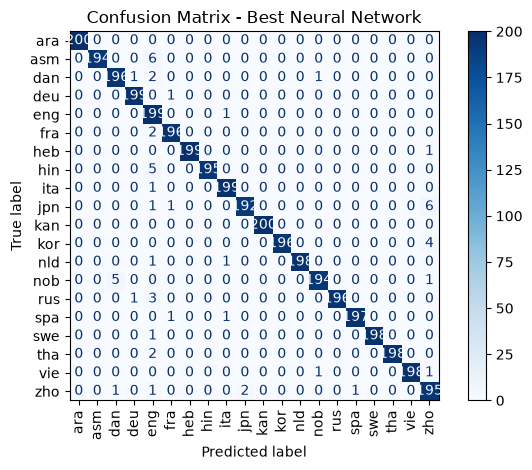

In [20]:
# 7. CONFUSION MATRIX

print("\nConfusion Matrix:\n")
cm = confusion_matrix(
    y_test,
    y_pred
)
print(cm)


# Visual confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(
    cmap='Blues',
    xticks_rotation=90
)
plt.title("Confusion Matrix - Best Neural Network")
plt.tight_layout()
plt.show()

In [21]:
# 8. TRAINING HISTORY
net = best_model.named_steps['net']

print(
    "\nEpochs trained:",
    len(net.history)
)
print(
    "Best validation loss:",
    min(net.history[:, 'valid_loss'])
)


Epochs trained: 10
Best validation loss: 0.06691066635854735



---

## Lab report

📝❓ Write your lab report here, addressing all questions in the notebook. For convenience, the questions are collected below; please keep your answers clearly marked.

### Questions

- 📝❓ Report your best hyperparameter combination.
- 📝❓ What is the effect of your modifications on validation performance? Discuss potential reasons.

## Declarations

Please fill in both declarations below by editing this cell (double-click it). Mark the applicable option by replacing ☐ with ☒ (copy the symbol from here: ☒) and complete the text field where required. Your reviewers will check that both declarations are present and completed.

### Contribution declaration

By submitting this work, the group declares that the contributions of the group members were:

☐ approximately equal

☐ not approximately equal

If the contributions were not approximately equal, no individual group member needs to be identified.

### Declaration on the use of AI

The group declares that any use of AI-based tools in preparing this work complied with the rules specified for this exercise.

☐ No AI-based tools were used.

☐ AI-based tools were used in accordance with the rules of the exercise.

If AI-based tools were used, briefly state the tool(s) used and the purpose(s) for which they were used:

